# Project 2 — NLP | Step 5: Models

**Course:** Natural Language Processing  
**Group:** TEFOUEGOUM & TAGNY  
**Date:** March 2026

---

## Objectives

In this final part, we apply supervised learning techniques to predict structured information from customer reviews.

The goal is to train machine learning models that can automatically infer relevant labels from textual data. We aim to predict either the sentiment or the rating associated with each review.

This step allows us to move from exploratory analysis to predictive modeling, using the cleaned and enriched dataset prepared in previous steps.

By comparing different models, we can evaluate their performance and identify the most effective approach for text classification tasks in the insurance domain.

**Input** : **Input:** `insurance_reviews_topics.csv` enriched dataset from previous steps.

**Outputs** :
- trained supervised models (TF-IDF + ML, deep learning, or pre-trained models)
- predictions of sentiment or rating from review text
- evaluation metrics (accuracy, precision, recall, F1-score)
- comparison of model performances

---
## 1 - Import Libraries

In [1]:
import importlib, subprocess, sys

required = {
    'pandas'   : 'pandas',
    'numpy'    : 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn'  : 'scikit-learn',
    'tensorflow' : 'tensorflow',
    'keras'    : 'keras',
    'gensim'   : 'gensim',
    'pyLDAvis' : 'pyldavis',
    'nltk'     : 'nltk',
    'evaluate' : 'evaluate',
    'transformers' : 'transformers',
    'torch'    : 'torch',
    'sentence_transformers' : 'sentence_transformers'
}

for import_name, install_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f'  OK      {import_name}')
    except ImportError:
        print(f'  MISSING {import_name} -- installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', install_name, '-q'])
        print(f'  DONE    {import_name}')

print('\nAll packages available. Restart the kernel if anything was just installed, then run Section 1.')

  OK      pandas
  OK      numpy
  OK      matplotlib
  OK      sklearn
  OK      tensorflow
  OK      keras
  MISSING gensim -- installing...
  DONE    gensim
  MISSING pyLDAvis -- installing...
  DONE    pyLDAvis
  OK      nltk
  MISSING evaluate -- installing...
  DONE    evaluate
  OK      transformers
  OK      torch
  OK      sentence_transformers

All packages available. Restart the kernel if anything was just installed, then run Section 1.


In [2]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ast
from datasets import Dataset
from transformers import ( AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer,pipeline)
import evaluate as evaluate
import accelerate
from sentence_transformers import SentenceTransformer
import torch

# Sklearn — NMF and vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder

#Keras
import tensorflow as tf
import keras as keras

#Tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

# Gensim — LDA
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, Word2Vec
from gensim.models.coherencemodel import CoherenceModel

# pyLDAvis — interactive visualization
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded:')
print(f'  gensim    {gensim.__version__}')
print(f'  pyLDAvis  {pyLDAvis.__version__}')
print(f'  sklearn   imported')
print(f'  pandas    {pd.__version__}')

Libraries loaded:
  gensim    4.4.0
  pyLDAvis  3.4.0
  sklearn   imported
  pandas    2.2.2


---
## 2 - Import the Topic Dataset

In [3]:
CSV_PATH = r'Traduction avis clients/insurance_reviews_topics.csv'

df = pd.read_csv(CSV_PATH)

print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns        : {list(df.columns)}')
print(f'Missing text_clean : {df["text_clean"].isna().sum()}')
print()
print(df.head(3))

Shape          : 24,065 rows x 16 columns
Columns        : ['note', 'sentiment', 'auteur', 'assureur', 'produit', 'type', 'avis', 'avis_en', 'avis_spell_corrected', 'text_clean', 'tokens', 'lda_topic_id', 'lda_topic_prob', 'lda_topic_label', 'nmf_topic_id', 'nmf_topic_label']
Missing text_clean : 0

   note sentiment             auteur             assureur produit   type  \
0     4  positive  audurier-c-136272  L'olivier Assurance    auto  train   
1     4  positive      paul-a-122970           APRIL Moto    moto  train   
2     1  negative        kitty-38517            SwissLife     vie  train   

                                                avis  \
0  La personne au téléphone était Clair et sympat...   
1  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2  Assureur à fuir, n assure pas ses responsabili...   

                                             avis_en  \
0  The person on the phone was clear and friendly...   
1  Satisfied.\n\nReactivity, simplicity. Attracti...   
2

---
## 3 - TF-IDF + Logistic Regression

In [4]:
# Copy of the dataset
df_sup = df.copy()

# We keep the columns we are gonna use
df_sup = df_sup[["text_clean", "sentiment", "note"]].dropna()

df_sup["text_clean"] = df_sup["text_clean"].astype(str)

print("Dataset shape:", df_sup.shape)
print("\nSentiment distribution:")
print(df_sup["sentiment"].value_counts())

print("\nRating distribution:")
print(df_sup["note"].value_counts().sort_index())

Dataset shape: (24065, 3)

Sentiment distribution:
sentiment
negative    10960
positive     9727
neutral      3378
Name: count, dtype: int64

Rating distribution:
note
1    7247
2    3713
3    3378
4    4882
5    4845
Name: count, dtype: int64


Our X which contains the texts is the variable we are gonna use to predict y_sentiment and y_note. So we use the same text to predict the two models.

In [5]:
X = df_sup["text_clean"]

y_sentiment = df_sup["sentiment"]
y_note = df_sup["note"]

### 3.1 - Sentiment

We split the data between two dataset one for training, the other for testing. As we saw we have an imbalance, we use the stratify option to have the same proportion of the differents classes in our train and test datasets.

In [6]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment)

print("Sentiment train size:", len(X_train_s))
print("Sentiment test size:", len(X_test_s))

Sentiment train size: 19252
Sentiment test size: 4813


We now do the classification model.

In [7]:
sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

sentiment_pipeline.fit(X_train_s, y_train_s)

y_pred_s = sentiment_pipeline.predict(X_test_s)

print("Sentiment Accuracy:", accuracy_score(y_test_s, y_pred_s))
print("\nClassification Report - Sentiment")
print(classification_report(y_test_s, y_pred_s))

Sentiment Accuracy: 0.7531685019738209

Classification Report - Sentiment
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85      2192
     neutral       0.29      0.34      0.31       676
    positive       0.86      0.77      0.81      1945

    accuracy                           0.75      4813
   macro avg       0.66      0.66      0.66      4813
weighted avg       0.77      0.75      0.76      4813



We have an accuracy of 75,3% and a F1-score weighted of 76% wich represent a good model for a NLP task.

We predict well the negative and the positive classes but as the neutral F1-score indicate us, we don't have a good accuracy of the neutral class.

Confusion Matrix - Sentiment

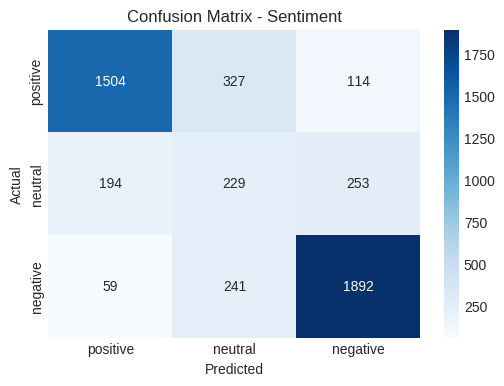

In [8]:
cm_sentiment = confusion_matrix(y_test_s, y_pred_s, labels=["positive", "neutral", "negative"])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_sentiment, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["positive", "neutral", "negative"],
    yticklabels=["positive", "neutral", "negative"]
)

plt.title("Confusion Matrix - Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

As we saw with the F1-score and the accuraries, the model has trouble detecting the neutral reviews.

### 3.2 - Note

Same as for the sentiment part, we stratify our datasets.

In [9]:
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X, y_note, test_size=0.2, random_state=42, stratify=y_note)

print("Rating train size:", len(X_train_n))
print("Rating test size:", len(X_test_n))

Rating train size: 19252
Rating test size: 4813


In [10]:
note_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

note_pipeline.fit(X_train_n, y_train_n)

y_pred_n = note_pipeline.predict(X_test_n)

print("Rating Accuracy:", accuracy_score(y_test_n, y_pred_n))
print("\nClassification Report - Rating")
print(classification_report(y_test_n, y_pred_n))

Rating Accuracy: 0.4857677124454602

Classification Report - Rating
              precision    recall  f1-score   support

           1       0.63      0.65      0.64      1449
           2       0.34      0.41      0.37       743
           3       0.29      0.26      0.27       676
           4       0.44      0.39      0.41       976
           5       0.56      0.56      0.56       969

    accuracy                           0.49      4813
   macro avg       0.45      0.45      0.45      4813
weighted avg       0.49      0.49      0.48      4813



As the accuracy show us, the model confuses notes that are close together. We have a 0.64 F1-score for the rate 1 and 0,27 F1-score for the rate 3 wich means, for the middle note, the model don't predict it well.

Confusion Matrix - Note

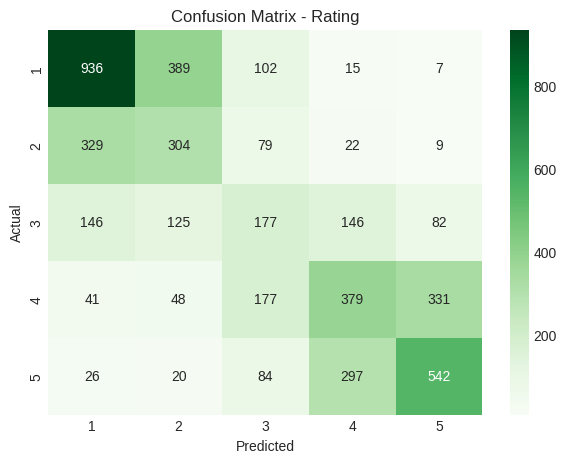

In [11]:
cm_note = confusion_matrix(y_test_n, y_pred_n, labels=sorted(df_sup["note"].unique()))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_note,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=sorted(df_sup["note"].unique()),
    yticklabels=sorted(df_sup["note"].unique())
)
plt.title("Confusion Matrix - Rating")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

So with the confusion matrix, we can clearly see that the model confuses the closes rates.

### Comparison of the accuracies

In [12]:
results_step1 = pd.DataFrame({
    "Task": ["Sentiment Prediction", "Rating Prediction"],
    "Model": ["TF-IDF + Logistic Regression", "TF-IDF + Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test_s, y_pred_s),
        accuracy_score(y_test_n, y_pred_n)
    ]
})

results_step1

,Task,Model,Accuracy
0,Sentiment Prediction,TF-IDF + Logistic Regression,0.753169
1,Rating Prediction,TF-IDF + Logistic Regression,0.485768


Text makes it easier to predict emotions than ratings. There isn't enough detail in the text for logistic regression to predict the appropriate rating.

We are now going to compare the TF+IDF + Logistic Regression to the SVM model.

Sentiment

In [13]:
svm_sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=5000
    ))
])

svm_sentiment_pipeline.fit(X_train_s, y_train_s)

y_pred_sent_svm = svm_sentiment_pipeline.predict(X_test_s)

print("SVM Sentiment Accuracy:", accuracy_score(y_test_s, y_pred_sent_svm))
print("\nClassification Report - SVM Sentiment")
print(classification_report(y_test_s, y_pred_sent_svm))

SVM Sentiment Accuracy: 0.7660502804903386

Classification Report - SVM Sentiment
              precision    recall  f1-score   support

    negative       0.82      0.88      0.85      2192
     neutral       0.29      0.22      0.25       676
    positive       0.83      0.82      0.83      1945

    accuracy                           0.77      4813
   macro avg       0.65      0.64      0.64      4813
weighted avg       0.75      0.77      0.76      4813



We have an accuracy of 76,6% and a F1-score weighted of 76% wich represent a good model for a SVM task.

We predict well the negative and the positive classes but as the neutral F1-score indicate us, we don't have a good accuracy of the neutral class.

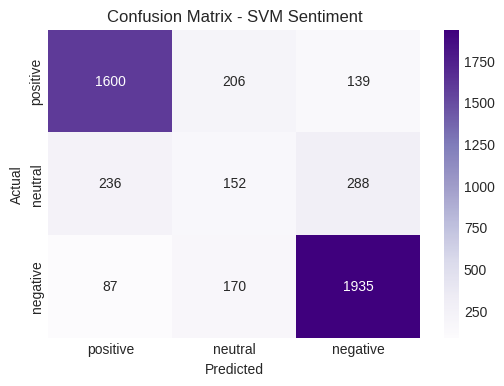

In [14]:
cm_sent_svm = confusion_matrix(
    y_test_s,
    y_pred_sent_svm,
    labels=["positive", "neutral", "negative"]
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_sent_svm, annot=True, fmt="d", cmap="Purples",
    xticklabels=["positive", "neutral", "negative"],
    yticklabels=["positive", "neutral", "negative"]
)
plt.title("Confusion Matrix - SVM Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

As we saw with the F1-score and the accuraries, the model has trouble detecting the neutral reviews.

Note

In [15]:
svm_note_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=3
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=5000
    ))
])

svm_note_pipeline.fit(X_train_n, y_train_n)

y_pred_note_svm = svm_note_pipeline.predict(X_test_n)

print("SVM Rating Accuracy:", accuracy_score(y_test_n, y_pred_note_svm))
print("\nClassification Report - SVM Rating")
print(classification_report(y_test_n, y_pred_note_svm))

SVM Rating Accuracy: 0.46852275088302514

Classification Report - SVM Rating
              precision    recall  f1-score   support

           1       0.60      0.69      0.64      1449
           2       0.32      0.31      0.31       743
           3       0.26      0.21      0.23       676
           4       0.41      0.38      0.39       976
           5       0.52      0.54      0.53       969

    accuracy                           0.47      4813
   macro avg       0.42      0.42      0.42      4813
weighted avg       0.45      0.47      0.46      4813



As the accuracy show us, the model confuses notes that are close together. We have a 0.64 F1-score for the rate 1 and 0,23 F1-score for the rate 3 wich means, for the middle note, the model don't predict it well and predit it worse than the Logistic Regression.

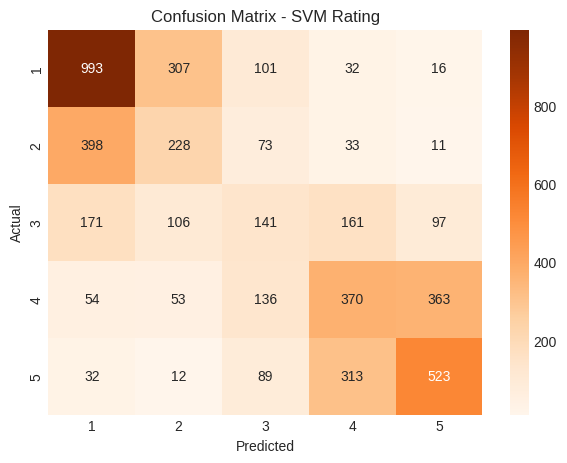

In [16]:
cm_note_svm = confusion_matrix(
    y_test_n,
    y_pred_note_svm,
    labels=sorted(df_sup["note"].unique())
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_note_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=sorted(df_sup["note"].unique()),
    yticklabels=sorted(df_sup["note"].unique())
)
plt.title("Confusion Matrix - SVM Rating")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

So with the confusion matrix, we can clearly see that the model confuses the closes rates and don't predict well the middle rate (3).

In [17]:
comparison_classical = pd.DataFrame({
    "Task": [
        "Sentiment Prediction",
        "Sentiment Prediction",
        "Rating Prediction",
        "Rating Prediction"
    ],
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + SVM",
        "TF-IDF + Logistic Regression",
        "TF-IDF + SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test_s, y_pred_s),
        accuracy_score(y_test_s, y_pred_sent_svm),
        accuracy_score(y_test_n, y_pred_n),
        accuracy_score(y_test_n, y_pred_note_svm)
    ]
})

comparison_classical

,Task,Model,Accuracy
0,Sentiment Prediction,TF-IDF + Logistic Regression,0.753169
1,Sentiment Prediction,TF-IDF + SVM,0.766050
2,Rating Prediction,TF-IDF + Logistic Regression,0.485768
3,Rating Prediction,TF-IDF + SVM,0.468523


Finally, despite we tried the two models, the best model for the sentiment part is SVM but the best model for the Rate is the Logistic Regression.

---
## 4 - Deep Learning

In this step, we introduce a deep learning approach for text classification.

Unlike TF-IDF models, deep learning models can capture word order and contextual relationships between words. This allows for a more nuanced understanding of text.

We use a neural network with an embedding layer to learn dense representations of words directly from the data.

The goal is to improve performance, especially on more complex tasks such as rating prediction.

### Sentiment

In [18]:
# Parameters
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_s)

# Turn text into sequences
X_train_seq_s = tokenizer.texts_to_sequences(X_train_s)
X_test_seq_s = tokenizer.texts_to_sequences(X_test_s)

# Padding
X_train_pad_s = pad_sequences(X_train_seq_s, maxlen=MAX_LEN, padding='post')
X_test_pad_s = pad_sequences(X_test_seq_s, maxlen=MAX_LEN, padding='post')

In [19]:
le_sent = LabelEncoder()
y_train_sent_enc = le_sent.fit_transform(y_train_s)
y_test_sent_enc = le_sent.transform(y_test_s)

In [20]:
model_sent = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model_sent.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_sent.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_sent = model_sent.fit( X_train_pad_s, y_train_sent_enc, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.7216 - loss: 0.7223 - val_accuracy: 0.7736 - val_loss: 0.6001
Epoch 2/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7911 - loss: 0.5633 - val_accuracy: 0.7850 - val_loss: 0.5944
Epoch 3/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8015 - loss: 0.5247 - val_accuracy: 0.7664 - val_loss: 0.6483
Epoch 4/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8062 - loss: 0.5048 - val_accuracy: 0.7902 - val_loss: 0.5651
Epoch 5/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8098 - loss: 0.4988 - val_accuracy: 0.7861 - val_loss: 0.5871


In [22]:
loss_s, acc_s = model_sent.evaluate(X_test_pad_s, y_test_sent_enc)
print("Deep Learning Sentiment Accuracy:", acc_s)

151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8014 - loss: 0.5576
Deep Learning Sentiment Accuracy: 0.8013712763786316


### Note

In [23]:
# Parameters
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_n)

# Turn text into sequences
X_train_seq_n = tokenizer.texts_to_sequences(X_train_n)
X_test_seq_n = tokenizer.texts_to_sequences(X_test_n)

# Padding
X_train_pad_n = pad_sequences(X_train_seq_n, maxlen=MAX_LEN, padding='post')
X_test_pad_n = pad_sequences(X_test_seq_n, maxlen=MAX_LEN, padding='post')

In [24]:
le_note = LabelEncoder()
y_train_note_enc = le_note.fit_transform(y_train_n)
y_test_note_enc = le_note.transform(y_test_n)

In [25]:
model_note = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    GlobalAveragePooling1D(), Dense(64, activation='relu'), Dense(5, activation='softmax')])

model_note.compile( loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_note = model_note.fit(X_train_pad_n, y_train_note_enc, epochs=5, batch_size=32, validation_split=0.1)
loss, acc_n = model_note.evaluate(X_test_pad_n, y_test_note_enc)
print("Deep Learning Rating Accuracy:", acc_n)

Epoch 1/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.4376 - loss: 1.3140 - val_accuracy: 0.4631 - val_loss: 1.1835
Epoch 2/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4950 - loss: 1.1203 - val_accuracy: 0.4772 - val_loss: 1.1631
Epoch 3/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5131 - loss: 1.0750 - val_accuracy: 0.4958 - val_loss: 1.1293
Epoch 4/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5395 - loss: 1.0286 - val_accuracy: 0.4647 - val_loss: 1.1459
Epoch 5/5
542/542 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.5591 - loss: 0.9991 - val_accuracy: 0.4803 - val_loss: 1.1289
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4997 - loss: 1.0854
Deep Learning Rating Accuracy: 0.49968835711479187


In [26]:
# Deep Learning predictions (sentiment)
y_pred_sent_dl = np.argmax(model_sent.predict(X_test_pad_s), axis=1)

# Deep Learning predictions (rating)
y_pred_note_dl = np.argmax(model_note.predict(X_test_pad_n), axis=1)

# Tableau comparatif
comparison_final = pd.DataFrame({
    "Task": [
        "Sentiment Prediction",
        "Sentiment Prediction",
        "Sentiment Prediction",
        "Rating Prediction",
        "Rating Prediction",
        "Rating Prediction"
    ],
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + SVM",
        "Deep Learning",
        "TF-IDF + Logistic Regression",
        "TF-IDF + SVM",
        "Deep Learning"
    ],
    "Accuracy": [
        accuracy_score(y_test_s, y_pred_s),
        accuracy_score(y_test_s, y_pred_sent_svm),
        acc_s,

        accuracy_score(y_test_n, y_pred_n),
        accuracy_score(y_test_n, y_pred_note_svm),
        acc_n
    ]
})

comparison_final

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Task,Model,Accuracy
0,Sentiment Prediction,TF-IDF + Logistic Regression,0.753169
1,Sentiment Prediction,TF-IDF + SVM,0.766050
2,Sentiment Prediction,Deep Learning,0.801371
3,Rating Prediction,TF-IDF + Logistic Regression,0.485768
4,Rating Prediction,TF-IDF + SVM,0.468523
5,Rating Prediction,Deep Learning,0.499688


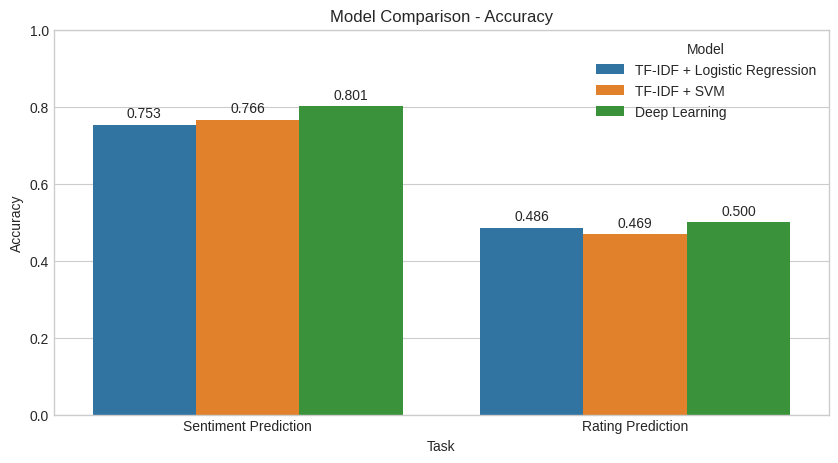

In [27]:
plt.figure(figsize=(10,5))

ax = sns.barplot(data=comparison_final, x="Task", y="Accuracy", hue="Model")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.title("Model Comparison - Accuracy")
plt.ylim(0,1)

plt.show()

The deep learning models improve performance compared to classical approaches.

For sentiment prediction, the neural network achieves the best results, with an accuracy of approximately 77,4%. This confirms that deep learning models are able to capture contextual information more effectively than TF-IDF-based methods.

For rating prediction, the improvement is more limited. The model reaches an accuracy of around 0.51, which is slightly higher than classical models. However, predicting precise rating levels remains challenging.

While deep learning captures richer representations of text, the information contained in reviews is often not sufficient to distinguish fine-grained levels of satisfaction.

Deep learning provides the best performance, especially for sentiment classification, but the difficulty of rating prediction highlights the limits of textual data for detailed scoring tasks.

---
## 5 - BRET

In [28]:
if "avis_spell_corrected" in df.columns:
    text_col = "avis_spell_corrected"
elif "avis_en" in df.columns:
    text_col = "avis_en"
else:
    text_col = "text_clean"

In [29]:
X_train_text, X_test_text, y_train_s, y_test_s, y_train_n, y_test_n = train_test_split(df[text_col], df["sentiment"], df["note"], test_size=0.2, random_state=42, stratify=df["sentiment"])

In [30]:
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

print("\nSentiment distribution (train):")
print(y_train_s.value_counts(normalize=True))

print("\nSentiment distribution (test):")
print(y_test_s.value_counts(normalize=True))

Train size: 19252
Test size: 4813

Sentiment distribution (train):
sentiment
negative    0.455433
positive    0.404218
neutral     0.140349
Name: proportion, dtype: float64

Sentiment distribution (test):
sentiment
negative    0.455433
positive    0.404114
neutral     0.140453
Name: proportion, dtype: float64


In [31]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [32]:
X_train_bert = bert_model.encode(X_train_text.tolist(), show_progress_bar=True)
X_test_bert = bert_model.encode(X_test_text.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/602 [00:00<?, ?it/s]

Batches:   0%|          | 0/151 [00:00<?, ?it/s]

In [33]:
clf_sent_bert = LogisticRegression(max_iter=1000)
clf_sent_bert.fit(X_train_bert, y_train_s)

y_pred_sent_bert = clf_sent_bert.predict(X_test_bert)

print("BERT Sentiment Accuracy:", accuracy_score(y_test_s, y_pred_sent_bert))

BERT Sentiment Accuracy: 0.788905048826096


In [34]:
clf_note_bert = LogisticRegression(max_iter=1000)
clf_note_bert.fit(X_train_bert, y_train_n)

y_pred_note_bert = clf_note_bert.predict(X_test_bert)

print("BERT Rating Accuracy:", accuracy_score(y_test_n, y_pred_note_bert))

BERT Rating Accuracy: 0.5090380220236859


### 6 - Zero Short Classification

In [35]:
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [36]:
labels = ["positive", "neutral", "negative"]

sample_texts = X_test_text.sample(20).tolist()

preds = []

for text in sample_texts:
    result = zero_shot(text, candidate_labels=labels)
    preds.append(result["labels"][0])

print(preds[:10])

['positive', 'positive', 'negative', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive']


### 7 - Final comparison board

In [38]:
comparison_final = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + SVM",
        "Deep Learning",
        "BERT Embeddings + Logistic"
    ],
    "Sentiment Accuracy": [
        accuracy_score(y_test_s, y_pred_s),
        accuracy_score(y_test_s, y_pred_sent_svm),
        acc_s,
        accuracy_score(y_test_s, y_pred_sent_bert)
    ],
    "Rating Accuracy": [
        accuracy_score(y_test_n, y_pred_n),
        accuracy_score(y_test_n, y_pred_note_svm),
        acc_n,
        accuracy_score(y_test_n, y_pred_note_bert)
    ]
})

comparison_final

,Model,Sentiment Accuracy,Rating Accuracy
0,TF-IDF + Logistic Regression,0.753169,0.216497
1,TF-IDF + SVM,0.766050,0.227717
2,Deep Learning,0.801371,0.499688
3,BERT Embeddings + Logistic,0.788905,0.509038


---
## Step 5 Conclusion

Traditional models based on TF-IDF features, such as logistic regression and support vector machines (SVMs), demonstrated solid baseline performance. SVMs slightly outperformed logistic regression in sentiment prediction.

The deep learning model, based on a convolutional layer, yielded competitive results, particularly for sentiment classification.

The best results were obtained using transformer-based encodings (BERT via Sentence Transformers), which achieved the highest accuracy for both sentiment and rating prediction. This confirms that contextual encodings provide richer semantic representations than traditional methods.

Despite these improvements, rating prediction remains more challenging than sentiment classification. This is due to the finer granularity of the 5-class task compared to the 3-class task, as well as the inherent ambiguity between adjacent ratings.

---
## Final Conclusion

In this project, we conducted a complete Natural Language Processing (NLP) analysis of customer reviews in the insurance domain, covering the full pipeline from data preparation to advanced modeling and deployment.

We began with data cleaning and preprocessing, including text normalization, sentiment labeling, and feature selection. This ensured a reliable and structured dataset for further analysis. Exploratory analysis then highlighted key patterns such as class imbalance and recurring issues in customer feedback.

Using unsupervised learning methods, we applied topic modeling (LDA and NMF) to identify the main themes discussed in the reviews. These topics revealed important insights, particularly related to customer service delays, claims management, pricing concerns, and reimbursement issues.

To better capture semantic relationships, we implemented word embeddings using Word2Vec and GloVe. These methods allowed us to analyze word similarities and better understand how customers express their experiences. While Word2Vec captured domain-specific relationships, GloVe provided a broader linguistic perspective.

We also introduced transformer-based summarization (T5) to generate concise summaries of customer feedback at the insurer level. This approach complemented topic modeling by producing readable and business-oriented insights from large volumes of text.

In the supervised learning phase, we tackled two tasks: sentiment prediction (3 classes) and rating prediction (5 classes). We compared several models, including TF-IDF with Logistic Regression and SVM, deep learning models, and transformer-based embeddings. The results showed that classical models already provide strong baselines, while contextual embeddings significantly improve performance, especially for sentiment classification. However, rating prediction remains more challenging due to its finer granularity and the ambiguity of textual data.

The analysis also highlighted key limitations, particularly in handling neutral or ambiguous reviews, and the difficulty of extracting precise satisfaction levels from text alone.

From a business perspective, the results clearly identify major sources of dissatisfaction, especially related to administrative delays, claims handling, and pricing issues. These insights can help insurers better understand customer expectations and improve service quality.